# CC 303 Project – Myth Clustering with TF-IDF and K-Means

This notebook is the technical companion to my project commentary.  
It:
1. Defines the myth passages and theme tags.
2. Builds TF-IDF vectors for each passage.
3. Runs k-means clustering (main model: k = 4).
4. Visualizes cluster structure and compares cluster assignments for k = 3, 4, 5.


## 1. Data: Myth Passages

Each myth passage is stored as a Python dictionary with:
- basic info (`id`, `title`, `work`, `author`, `book`)
- the English `text`
- my theme `tags` (e.g., xenia, hubris, fate)
- a one-sentence `lesson` in my own words


In [1]:
myths = [
    {
        "id": "telemachus_suitors",
        "title": "Telemachus Confronts the Suitors",
        "work": "Odyssey",
        "author": "Homer",
        "book": 1,
        "lines": "Od. 1.368–420 (Butler)",
        "text": """Then Telemachus spoke, “Shameless,” he cried, “and insolent suitors, let us feast at our pleasure now, and let there be no brawling, for it is a rare thing to hear a man with such a divine voice as Phemius has; but in the morning meet me in full assembly that I may give you formal notice to depart, and feast at one another’s houses, turn and turn about, at your own cost. If on the other hand you choose to persist in spunging upon one man, heaven help me, but Jove shall reckon with you in full, and when you fall in my father’s house there shall be no man to avenge you.”

The suitors bit their lips as they heard him, and marvelled at the boldness of his speech. Then, Antinous, son of Eupeithes, said, “The gods seem to have given you lessons in bluster and tall talking; may Jove never grant you to be chief in Ithaca as your father was before you.”

Telemachus answered, “Antinous, do not chide with me, but, god willing, I will be chief too if I can. Is this the worst fate you can think of for me? It is no bad thing to be a chief, for it brings both riches and honour. Still, now that Ulysses is dead there are many great men in Ithaca both old and young, and some other may take the lead among them; nevertheless I will be chief in my own house, and will rule those whom Ulysses has won for me.”
""",
        "tags": ["xenia", "justice", "coming_of_age"],
        "lesson": "Telemachus stands up to the suitors and starts acting like the head of the household by defending proper hospitality."
    },

    {
        "id": "cyclops_violated_xenia",
        "title": "Polyphemus Rejects Hospitality",
        "work": "Odyssey",
        "author": "Homer",
        "book": 9,
        "lines": "Od. 9.272–307 (Butler)",
        "text": """ “To this he gave me but a pitiless answer, ‘Stranger,’ said he, ‘you are a fool, or else you know nothing of this country. Talk to me, indeed, about fearing the gods or shunning their anger? We Cyclopes do not care about Jove or any of your blessed gods, for we are ever so much stronger than they. I shall not spare either yourself or your companions out of any regard for Jove, unless I am in the humour for doing so. And now tell me where you made your ship fast when you came on shore. Was it round the point, or is she lying straight off the land?’

“He said this to draw me out, but I was too cunning to be caught in that way, so I answered with a lie; ‘Neptune,’ said I, ‘sent my ship on to the rocks at the far end of your country, and wrecked it. We were driven on to them from the open sea, but I and those who are with me escaped the jaws of death.’

“The cruel wretch vouchsafed me not one word of answer, but with a sudden clutch he gripped up two of my men at once and dashed them down upon the ground as though they had been puppies. Their brains were shed upon the ground, and the earth was wet with their blood. Then he tore them limb from limb and supped upon them. He gobbled them up like a lion in the wilderness, flesh, bones, marrow, and entrails, without leaving anything uneaten. As for us, we wept and lifted up our hands to heaven on seeing such a horrid sight, for we did not know what else to do;
""",
        "tags": ["xenia", "brutality", "divine_law"],
        "lesson": "Polyphemus breaks every rule of hospitality and shows no fear of the gods who protect strangers and guests."
    },

    {
        "id": "cyclops_boast_curse",
        "title": "Odysseus’ Boast and the Cyclops’ Curse",
        "work": "Odyssey",
        "author": "Homer",
        "book": 9,
        "lines": "Od. 9.500–542 (Butler)",
        "text": """“But I would not listen to them, and shouted out to him in my rage, ‘Cyclops, if any one asks you who it was that put your eye out and spoiled your beauty, say it was the valiant warrior Ulysses, son of Laertes, who lives in Ithaca.’

“On this he groaned, and cried out, ‘Alas, alas, then the old prophecy about me is coming true. There was a prophet here, at one time, a man both brave and of great stature, Telemus son of Eurymus, who was an excellent seer, and did all the prophesying for the Cyclopes till he grew old; he told me that all this would happen to me some day, and said I should lose my sight by the hand of Ulysses. I have been all along expecting some one of imposing presence and superhuman strength, whereas he turns out to be a little insignificant weakling, who has managed to blind my eye by taking advantage of me in my drink; come here, then, Ulysses, that I may make you presents to show my hospitality, and urge Neptune to help you forward on your journey—for Neptune and I are father and son. He, if he so will, shall heal me, which no one else neither god nor man can do.’

“Then I said, ‘I wish I could be as sure of killing you outright and sending you down to the house of Hades, as I am that it will take more than Neptune to cure that eye of yours.’

“On this he lifted up his hands to the firmament of heaven and prayed, saying, ‘Hear me, great Neptune; if I am indeed your own true begotten son, grant that Ulysses may never reach his home alive; or if he must get back to his friends at last, let him do so late and in sore plight after losing all his men [let him reach his home in another man’s ship and find trouble in his house.’
""",
        "tags": ["hubris", "fate", "consequences"],
        "lesson": "Odysseus ignores his crew and brags, which leads Polyphemus to call on Poseidon to curse his journey home."
    },

    {
        "id": "odysseus_nausicaa",
        "title": "Odysseus Speaks to Nausicaa",
        "work": "Odyssey",
        "author": "Homer",
        "book": 6,
        "lines": "Od. 6.149–185 (Butler)",
        "text": """ “O queen,” he said, “I implore your aid—but tell me, are you a goddess or are you a mortal woman? If you are a goddess and dwell in heaven, I can only conjecture that you are Jove’s daughter Diana, for your face and figure resemble none but hers; if on the other hand you are a mortal and live on earth, thrice happy are your father and mother—thrice happy, too, are your brothers and sisters; how proud and delighted they must feel when they see so fair a scion as yourself going out to a dance; most happy, however, of all will he be whose wedding gifts have been the richest, and who takes you to his own home. I never yet saw any one so beautiful, neither man nor woman, and am lost in admiration as I behold you.
""",
        "tags": ["xenia", "cunning", "gender_roles"],
        "lesson": "Odysseus carefully flatters Nausicaa and stays respectful so he can get help within the rules of hospitality."
    },

    {
        "id": "circe_pigs",
        "title": "Circe Turns the Men into Swine",
        "work": "Odyssey",
        "author": "Homer",
        "book": 10,
        "lines": "Od. 10.229–243 (Butler)",
        "text": """ “They called her and she came down, unfastened the door, and bade them enter. They, thinking no evil, followed her, all except Eurylochus, who suspected mischief and staid outside. When she had got them into her house, she set them upon benches and seats and mixed them a mess with cheese, honey, meal, and Pramnian wine, but she drugged it with wicked poisons to make them forget their homes, and when they had drunk she turned them into pigs by a stroke of her wand, and shut them up in her pig-styes. They were like pigs—head, hair, and all, and they grunted just as pigs do; but their senses were the same as before, and they remembered everything.

“Thus then were they shut up squealing, and Circe threw them some acorns and beech masts such as pigs eat, but Eurylochus hurried back to tell me about the sad fate of our comrades.
""",
        "tags": ["temptation", "enchantment", "cunning_vs_naivety"],
        "lesson": "The men’s careless curiosity lets Circe trap them and turn them into animals, showing how temptation makes people easy to control."
    },

    {
        "id": "helios_cattle",
        "title": "The Slaughter of Helios’ Cattle",
        "work": "Odyssey",
        "author": "Homer",
        "book": 12,
        "lines": "Od. 12.339–365 (Butler)",
        "text": """ “Meanwhile Eurylochus had been giving evil counsel to the men, ‘Listen to me,’ said he, ‘my poor comrades. All deaths are bad enough but there is none so bad as famine. Why should not we drive in the best of these cows and offer them in sacrifice to the immortal gods? If we ever get back to Ithaca, we can build a fine temple to the sun-god and enrich it with every kind of ornament; if, however, he is determined to sink our ship out of revenge for these horned cattle, and the other gods are of the same mind, I for one would rather drink salt water once for all and have done with it, than be starved to death by inches in such a desert island as this is.’

“Thus spoke Eurylochus, and the men approved his words. Now the cattle, so fair and goodly, were feeding not far from the ship; the men, therefore, drove in the best of them, and they all stood round them saying their prayers, and using young oak-shoots instead of barley-meal, for there was no barley left. When they had done praying they killed the cows and dressed their carcasses; they cut out the thigh bones, wrapped them round in two layers of fat, and set some pieces of raw meat on top of them.
""",
        "tags": ["disobedience", "fate", "leadership_failure"],
        "lesson": "Eurylochus convinces the starving crew to kill the sacred cattle, showing how hunger and weak leadership lead to disobedience and disaster."
    } ,
        {
        "id": "calypso_double_standard",
        "title": "Calypso Complains About the Gods",
        "work": "Odyssey",
        "author": "Homer",
        "book": 5,
        "lines": "Od. 5.118–152 (Butler)",
        "text": """ Calypso trembled with rage when she heard this, “You gods,” she exclaimed, “ought to be ashamed of yourselves. You are always jealous and hate seeing a goddess take a fancy to a mortal man, and live with him in open matrimony. So when rosy-fingered Dawn made love to Orion, you precious gods were all of you furious till Diana went and killed him in Ortygia. So again when Ceres fell in love with Iasion, and yielded to him in a thrice-ploughed fallow field, Jove came to hear of it before so very long and killed Iasion with his thunderbolts. And now you are angry with me too because I have a man here. I found the poor creature sitting all alone astride of a keel, for Jove had struck his ship with lightning and sunk it in mid ocean, so that all his crew were drowned, while he himself was driven by wind and waves on to my island. I got fond of him and cherished him, and had set my heart on making him immortal, so that he should never grow old all his days; still I cannot cross Jove, nor bring his counsels to nothing; therefore, if he insists upon it, let the man go beyond the seas again; but I cannot send him anywhere myself for I have neither ships nor men who can take him. Nevertheless I will readily give him such advice, in all good faith, as will be likely to bring him safely to his own country.”


""",
        "tags": ["divine_power", "fate", "gender_double_standard"],
        "lesson": "Calypso calls out the gods’ double standards about goddesses and mortal lovers, but still has to obey Zeus and let Odysseus go."
    },

        {
        "id": "suitors_slaughter",
        "title": "Odysseus Kills Antinous and Condemns the Suitors",
        "work": "Odyssey",
        "author": "Homer",
        "book": 22,
        "lines": "Od. 22.8–41 (Butler)",
        "text": """ On this he aimed a deadly arrow at Antinous, who was about to take up a two-handled gold cup to drink his wine and already had it in his hands. He had no thought of death—who amongst all the revellers would think that one man, however brave, would stand alone among so many and kill him? The arrow struck Antinous in the throat, and the point went clean through his neck, so that he fell over and the cup dropped from his hand, while a thick stream of blood gushed from his nostrils. He kicked the table from him and upset the things on it, so that the bread and roasted meats were all soiled as they fell over on to the ground. The suitors were in an uproar when they saw that a man had been hit; they sprang in dismay one and all of them from their seats and looked everywhere towards the walls, but there was neither shield nor spear, and they rebuked Ulysses very angrily. “Stranger,” said they, “you shall pay for shooting people in this way: you shall see no other contest; you are a doomed man; he whom you have slain was the foremost youth in Ithaca, and the vultures shall devour you for having killed him.”

Thus they spoke, for they thought that he had killed Antinous by mistake, and did not perceive that death was hanging over the head of every one of them. But Ulysses glared at them and said:

“Dogs, did you think that I should not come back from Troy? You have wasted my substance, have forced my women servants to lie with you, and have wooed my wife while I was still living. You have feared neither God nor man, and now you shall die.”
""",
        "tags": ["justice", "xenia", "retribution"],
        "lesson": "Odysseus kills Antinous and tells the suitors they will die for abusing his hospitality, his household, and the gods’ rules."
    },

            {
        "id": "arachne_hubris",
        "title": "Arachne Challenges Minerva",
        "work": "Metamorphoses",
        "author": "Ovid",
        "book": 6,
        "lines": "Met. 6.1–53 (More)",
        "text": """ So graceful was her motion then,—if she was twisting the coarse wool in little balls, or if she teased it with her finger-tips, or if she softened the fine fleece, drawn forth in misty films, or if she twirled the smooth round spindle with her energetic thumb, or if with needle she embroidered cloth;—in all her motions one might well perceive how much Minerva had instructed her: but this she ever would deny, displeased to share her fame; and said, “Let her contend in art with me; and if her skill prevails, I then will forfeit all!” Minerva heard, and came to her, disguised with long grey hair, and with a staff to steady her weak limbs. She seemed a feeble woman, very old, and quavered as she said, “Old age is not the cause of every ill; experience comes with lengthened years; and, therefore, you should not despise my words. It is no harm in you to long for praise of mortals, when your nimble hands are spinning the soft wool,—but you should not deny Minerva's art—and you should pray that she may pardon you, for she will grant you pardon if you ask.” Arachne, scowling with an evil face. Looked at the goddess, as she dropped her thread. She hardly could restrain her threatening hand, and, trembling in her anger, she replied to you, disguised Minerva: “Silly fool,—worn out and witless in your palsied age, a great age is your great misfortune!—Let your daughter and your son's wife—if the Gods have blessed you—let them profit by your words; within myself, my knowledge is contained sufficient; you need not believe that your advice does any good; for I am quite unchanged in my opinion. Get you gone,—advise your goddess to come here herself, and not avoid the contest!” Instantly, the goddess said, “Minerva comes to you!” And with those brief words, put aside the shape of the old woman, and revealed herself, Minerva, goddess. All the other Nymphs and matrons of Mygdonia worshiped her; but not Arachne, who defiant stood;—although at first she flushed up—then went pale—then blushed again, reluctant.—So, at first, the sky suffuses, as Aurora moves, and, quickly when the glorious sun comes up, pales into white. She even rushed upon her own destruction, for she would not give from her desire to gain the victory.
""",
        "tags": ["hubris", "craft", "divine_punishment"],
        "lesson": "Arachne refuses to honor Minerva, insists on competing with a goddess, and her weaving skill plus pride lead directly to her punishment."
    },


        {
        "id": "niobe_hubris",
        "title": "Niobe’s Fall and Transformation",
        "work": "Metamorphoses",
        "author": "Ovid",
        "book": 6,
        "lines": "Met. 6.267–303 (More)",
        "text": """ Proud Niobe who but so lately drove her people from Latona's altars, while, moving majestic through the midst, she hears their plaudits, now so bitterly debased, her meanest enemy may pity her!—She fell upon the bodies of her sons, and in a frenzy of maternal grief, kissed their unfeeling lips. Then unto Heaven with arms accusing, railed upon her foe: “Glut your revenge! Latona, glut your rage! Yea, let my lamentations be your joy! Go—satiate your flinty heart with death! Are not my seven sons all dead? Am I not waiting to be carried to my grave?—exult and triumph, my victorious foe! Victorious? Nay!—Much more remains to me in all my utmost sorrow, than to you, you gloater upon vengeance—undismayed, I stand victorious in my Field of Woe!” No sooner had she spoken, than the cord twanged from the ever-ready bow; and all who heard the fatal sound, again were filled with fear,—save Niobe, in misery bold,—defiant in misfortune.—Clothed in black, the sisters of the stricken brothers stood, with hair disheveled, by the funeral biers. And one while plucking from her brother's heart a shaft, swooned unto death, fell on her face—on her dear brother's corpse. Another girl, while she consoled her mother, suddenly, was stricken with an unseen, deadly wound; and doubled in convulsions, closed her lips, tight held them, till both breath and life were lost. Another, vainly rushed away from death—she met it, and pitched head-first to the ground; and still another died upon her corse, another vainly sought a secret death, and, then another slipped beyond's life's edge. So, altogether, six of seven died—each victim, strickened in a different way. One child remained. Then in a frenzy-fear the mother, as she covered her with all her garments and her body, wailed—“Oh, leave me this one child! the youngest of them all! My darling daughter—only leave me one!” But even while she was entreating for its life—the life was taken from her only child. Childless—she crouched beside her slaughtered sons, her lifeless daughters, and her husband's corpse. The breeze not even moved her fallen hair, a chill of marble spread upon her flesh, beneath her pale, set brows, her eyes moved not, her bitter tongue turned stiff in her hard jaws, her lovely veins congealed, and her stiff neck and rigid hands could neither bend nor move.—her limbs and body, all were changed to stone. Yet ever would she weep: and as her tears were falling she was carried from the place, enveloped in a storm and mighty wind, far, to her native land, where fixed upon a mountain summit she dissolves in tears,—and to this day the marble drips with tears.
""",
        "tags": ["hubris", "grief", "divine_punishment"],
        "lesson": "Niobe boasts that she is greater than Latona because of her many children, and the slaughter of her family leaves her frozen in endless grief."
    },
        {
        "id": "eumaeus_hospitality",
        "title": "Eumaeus Welcomes the Stranger",
        "work": "Odyssey",
        "author": "Homer",
        "book": 14,
        "lines": "Od. 14.50–90 (Butler, approx.)",
        "text": """ To this you answered, O swineherd Eumaeus, “Stranger, though a still poorer man should come here, it would not be right for me to insult him, for all strangers and beggars are from Jove. You must take what you can get and be thankful, for servants live in fear when they have young lords for their masters; and this is my misfortune now, for heaven has hindered the return of him who would have been always good to me and given me something of my own—a house, a piece of land, a good looking wife, and all else that a liberal master allows a servant who has worked hard for him, and whose labour the gods have prospered as they have mine in the situation which I hold. If my master had grown old here he would have done great things by me, but he is gone, and I wish that Helen’s whole race were utterly destroyed, for she has been the death of many a good man. It was this matter that took my master to Ilius, the land of noble steeds, to fight the Trojans in the cause of king Agamemnon.”

As he spoke he bound his girdle round him and went to the styes where the young sucking pigs were penned. He picked out two which he brought back with him and sacrificed. He singed them, cut them up, and spitted them; when the meat was cooked he brought it all in and set it before Ulysses, hot and still on the spit, whereon Ulysses sprinkled it over with white barley meal. The swineherd then mixed wine in a bowl of ivy-wood, and taking a seat opposite Ulysses told him to begin.

“Fall to, stranger,” said he, “on a dish of servant’s pork. The fat pigs have to go to the suitors, who eat them up without shame or scruple; but the blessed gods love not such shameful doings, and respect those who do what is lawful and right. Even the fierce freebooters who go raiding on other people’s land, and Jove gives them their spoil—even they, when they have filled their ships and got home again live conscience-stricken, and look fearfully for judgement; but some god seems to have told these people that Ulysses is dead and gone; they will not, therefore, go back to their own homes and make their offers of marriage in the usual way, but waste his estate by force, without fear or stint.
""",
        "tags": ["xenia", "loyalty", "class"],
        "lesson": "Even as a poor servant, Eumaeus insists on treating strangers with respect, showing how xenia and loyalty survive below the elite level."
    },
        {
        "id": "argos_loyal_dog",
        "title": "Argos Recognizes Odysseus",
        "work": "Odyssey",
        "author": "Homer",
        "book": 17,
        "lines": "Od. 17.290–327 (Butler)",
        "text": """ As they were thus talking, a dog that had been lying asleep raised his head and pricked up his ears. This was Argos, whom Ulysses had bred before setting out for Troy, but he had never had any work out of him. In the old days he used to be taken out by the young men when they went hunting wild goats, or deer, or hares, but now that his master was gone he was lying neglected on the heaps of mule and cow dung that lay in front of the stable doors till the men should come and draw it away to manure the great close; and he was full of fleas. As soon as he saw Ulysses standing there, he dropped his ears and wagged his tail, but he could not get close up to his master. When Ulysses saw the dog on the other side of the yard, he dashed a tear from his eyes without Eumaeus seeing it, and said:

“Eumaeus, what a noble hound that is over yonder on the manure heap: his build is splendid; is he as fine a fellow as he looks, or is he only one of those dogs that come begging about a table, and are kept merely for show?”

“This hound,” answered Eumaeus, “belonged to him who has died in a far country. If he were what he was when Ulysses left for Troy, he would soon show you what he could do. There was not a wild beast in the forest that could get away from him when he was once on its tracks. But now he has fallen on evil times, for his master is dead and gone, and the women take no care of him. Servants never do their work when their master’s hand is no longer over them, for Jove takes half the goodness out of a man when he makes a slave of him.”

As he spoke he went inside the buildings to the cloister where the suitors were, but Argos died as soon as he had recognised his master.
""",
        "tags": ["loyalty", "homecoming", "neglect"],
        "lesson": "Argos recognizes Odysseus immediately after years of neglect, showing a painful contrast between loyal memory and a household that has given up."
    },
    {
        "id": "penelope_bow_contest",
        "title": "The Contest of the Bow",
        "work": "Odyssey",
        "author": "Homer",
        "book": 21,
        "lines": "Od. 21.118–376 (Butler)",
        "text": """ This done, he went on to the pavement to make trial of the bow; thrice did he tug at it, trying with all his might to draw the string, and thrice he had to leave off, though he had hoped to string the bow and shoot through the iron. He was trying for the fourth time, and would have strung it had not Ulysses made a sign to check him in spite of all his eagerness. So he said:

“Alas! I shall either be always feeble and of no prowess, or I am too young, and have not yet reached my full strength so as to be able to hold my own if any one attacks me. You others, therefore, who are stronger than I, make trial of the bow and get this contest settled.”

On this he put the bow down, letting it lean against the door [that led into the house] with the arrow standing against the top of the bow. Then he sat down on the seat from which he had risen, and Antinous said:

“Come on each of you in his turn, going towards the right from the place at which the cupbearer begins when he is handing round the wine.”

The rest agreed, and Leiodes son of Oenops was the first to rise. He was sacrificial priest to the suitors, and sat in the corner near the mixing-bowl. [163] He was the only man who hated their evil deeds and was indignant with the others. He was now the first to take the bow and arrow, so he went on to the pavement to make his trial, but he could not string the bow, for his hands were weak and unused to hard work, they therefore soon grew tired, and he said to the suitors, “My friends, I cannot string it; let another have it, this bow shall take the life and soul out of many a chief among us, for it is better to die than to live after having missed the prize that we have so long striven for, and which has brought us so long together. Some one of us is even now hoping and praying that he may marry Penelope, but when he has seen this bow and tried it, let him woo and make bridal offerings to some other woman, and let Penelope marry whoever makes her the best offer and whose lot it is to win her.”

On this he put the bow down, letting it lean against the door,[164] with the arrow standing against the tip of the bow. Then he took his seat again on the seat from which he had risen; and Antinous rebuked him saying:

“Leiodes, what are you talking about? Your words are monstrous and intolerable; it makes me angry to listen to you. Shall, then, this bow take the life of many a chief among us, merely because you cannot bend it yourself? True, you were not born to be an archer, but there are others who will soon string it.”

Then he said to Melanthius the goatherd, “Look sharp, light a fire in the court, and set a seat hard by with a sheep skin on it; bring us also a large ball of lard, from what they have in the house. Let us warm the bow and grease it—we will then make trial of it again, and bring the contest to an end.”

Melanthius lit the fire, and set a seat covered with sheep skins beside it. He also brought a great ball of lard from what they had in the house, and the suitors warmed the bow and again made trial of it, but they were none of them nearly strong enough to string it. Nevertheless there still remained Antinous and Eurymachus, who were the ringleaders among the suitors and much the foremost among them all.

Then the swineherd and the stockman left the cloisters together, and Ulysses followed them. When they had got outside the gates and the outer yard, Ulysses said to them quietly:

“Stockman, and you swineherd, I have something in my mind which I am in doubt whether to say or no; but I think I will say it. What manner of men would you be to stand by Ulysses, if some god should bring him back here all of a sudden? Say which you are disposed to do—to side with the suitors, or with Ulysses?”

“Father Jove,” answered the stockman, “would indeed that you might so ordain it. If some god were but to bring Ulysses back, you should see with what might and main I would fight for him.”

In like words Eumaeus prayed to all the gods that Ulysses might return; when, therefore, he saw for certain what mind they were of, Ulysses said, “It is I, Ulysses, who am here. I have suffered much, but at last, in the twentieth year, I am come back to my own country. I find that you two alone of all my servants are glad that I should do so, for I have not heard any of the others praying for my return. To you two, therefore, will I unfold the truth as it shall be. If heaven shall deliver the suitors into my hands, I will find wives for both of you, will give you house and holding close to my own, and you shall be to me as though you were brothers and friends of Telemachus. I will now give you convincing proofs that you may know me and be assured. See, here is the scar from the boar’s tooth that ripped me when I was out hunting on Mt. Parnassus with the sons of Autolycus.”

As he spoke he drew his rags aside from the great scar, and when they had examined it thoroughly, they both of them wept about Ulysses, threw their arms round him, and kissed his head and shoulders, while Ulysses kissed their hands and faces in return. The sun would have gone down upon their mourning if Ulysses had not checked them and said:

“Cease your weeping, lest some one should come outside and see us, and tell those who are within. When you go in, do so separately, not both together; I will go first, and do you follow afterwards; let this moreover be the token between us; the suitors will all of them try to prevent me from getting hold of the bow and quiver; do you, therefore, Eumaeus, place it in my hands when you are carrying it about, and tell the women to close the doors of their apartment. If they hear any groaning or uproar as of men fighting about the house, they must not come out; they must keep quiet, and stay where they are at their work. And I charge you, Philoetius, to make fast the doors of the outer court, and to bind them securely at once.”

When he had thus spoken, he went back to the house and took the seat that he had left. Presently, his two servants followed him inside.

At this moment the bow was in the hands of Eurymachus, who was warming it by the fire, but even so he could not string it, and he was greatly grieved. He heaved a deep sigh and said, “I grieve for myself and for us all; I grieve that I shall have to forgo the marriage, but I do not care nearly so much about this, for there are plenty of other women in Ithaca and elsewhere; what I feel most is the fact of our being so inferior to Ulysses in strength that we cannot string his bow. This will disgrace us in the eyes of those who are yet unborn.”

“It shall not be so, Eurymachus,” said Antinous, “and you know it yourself. Today is the feast of Apollo throughout all the land; who can string a bow on such a day as this? Put it on one side—as for the axes they can stay where they are, for no one is likely to come to the house and take them away: let the cupbearer go round with his cups, that we may make our drink-offerings and drop this matter of the bow; we will tell Melanthius to bring us in some goats tomorrow—the best he has; we can then offer thigh bones to Apollo the mighty archer, and again make trial of the bow, so as to bring the contest to an end.”

The rest approved his words, and thereon men servants poured water over the hands of the guests, while pages filled the mixing-bowls with wine and water and handed it round after giving every man his drink-offering. Then, when they had made their offerings and had drunk each as much as he desired, Ulysses craftily said:—

“Suitors of the illustrious queen, listen that I may speak even as I am minded. I appeal more especially to Eurymachus, and to Antinous who has just spoken with so much reason. Cease shooting for the present and leave the matter to the gods, but in the morning let heaven give victory to whom it will. For the moment, however, give me the bow
""",
        "tags": ["justice", "xenia", "hubris", "fate"],
        "lesson": "The suitors fail to string Odysseus’ bow while he, disguised as a beggar, quietly asks to try, setting up a test of true kingship and just revenge."
    },
    {
        "id": "sirens_song",
        "title": "Circe Warns Odysseus About the Sirens",
        "work": "Odyssey",
        "author": "Homer",
        "book": 12,
        "lines": "Od. 12.37–54 (Butler)",
        "text": """ “‘So far so good,’ said she, when I had ended my story, ‘and now pay attention to what I am about to tell you—heaven itself, indeed, will recall it to your recollection. First you will come to the Sirens who enchant all who come near them. If any one unwarily draws in too close and hears the singing of the Sirens, his wife and children will never welcome him home again, for they sit in a green field and warble him to death with the sweetness of their song. There is a great heap of dead men’s bones lying all around, with the flesh still rotting off them. Therefore pass these Sirens by, and stop your men’s ears with wax that none of them may hear; but if you like you can listen yourself, for you may get the men to bind you as you stand upright on a cross piece half way up the mast,[99] and they must lash the rope’s ends to the mast itself, that you may have the pleasure of listening. If you beg and pray the men to unloose you, then they must bind you faster.
""",
        "tags": ["temptation", "cunning", "fate"],
        "lesson": "Circe explains how the Sirens destroy sailors with sweet songs and teaches Odysseus to plan ahead so he can hear them without giving in."
    },
    {
        "id": "scylla_charybdis",
        "title": "Scylla and Charybdis Described",
        "work": "Odyssey",
        "author": "Homer",
        "book": 12,
        "lines": "Od. 12.73–110 (Butler)",
        "text": """ Inside it Scylla sits and yelps with a voice that you might take to be that of a young hound, but in truth she is a dreadful monster and no one—not even a god—could face her without being terror-struck. She has twelve mis-shapen feet, and six necks of the most prodigious length; and at the end of each neck she has a frightful head with three rows of teeth in each, all set very close together, so that they would crunch any one to death in a moment, and she sits deep within her shady cell thrusting out her heads and peering all round the rock, fishing for dolphins or dogfish or any larger monster that she can catch, of the thousands with which Amphitrite teems. No ship ever yet got past her without losing some men, for she shoots out all her heads at once, and carries off a man in each mouth.

“‘You will find the other rock lie lower, but they are so close together that there is not more than a bow-shot between them. [A large fig tree in full leaf[101] grows upon it], and under it lies the sucking whirlpool of Charybdis. Three times in the day does she vomit forth her waters, and three times she sucks them down again; see that you be not there when she is sucking, for if you are, Neptune himself could not save you; you must hug the Scylla side and drive ship by as fast as you can, for you had better lose six men than your whole crew.’
""",
        "tags": ["fate", "leadership_failure", "suffering"],
        "lesson": "Circe tells Odysseus he must choose the lesser disaster, accepting some deaths at Scylla rather than risk losing his whole crew to Charybdis."
    },
]


## 2. Methods: TF-IDF and k-means

I use:
- `TfidfVectorizer` to turn passage text into numerical vectors.
- `KMeans` to group passages into clusters.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

def build_tfidf(myths):
    """
    Take a list of myth dicts and return:
    - X: TF-IDF matrix (one row per myth)
    - vectorizer: the fitted TfidfVectorizer
    """
    texts = [m["text"] for m in myths]
    vectorizer = TfidfVectorizer(stop_words="english")
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

def run_kmeans(X, k, random_state=0, n_init=10):
    """
    Run k-means on TF-IDF matrix X with k clusters.
    Returns:
    - kmeans: fitted KMeans model
    - labels: cluster label for each row in X
    """
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    kmeans.fit(X)
    return kmeans, kmeans.labels_



## 3. Results: Main Model (k = 4)

Here I fit the TF-IDF model, run k-means with k = 4, and show:
- A table of passages and their cluster labels.
- A 2D PCA scatter plot colored by cluster.


TF-IDF shape (documents, features): (15, 1155)


,id,title,work,cluster_k4,tags
5,helios_cattle,The Slaughter of Helios’ Cattle,Odyssey,0,"disobedience, fate, leadership_failure"
14,scylla_charybdis,Scylla and Charybdis Described,Odyssey,0,"fate, leadership_failure, suffering"
13,sirens_song,Circe Warns Odysseus About the Sirens,Odyssey,0,"temptation, cunning, fate"
9,niobe_hubris,Niobe’s Fall and Transformation,Metamorphoses,1,"hubris, grief, divine_punishment"
11,argos_loyal_dog,Argos Recognizes Odysseus,Odyssey,1,"loyalty, homecoming, neglect"
4,circe_pigs,Circe Turns the Men into Swine,Odyssey,1,"temptation, enchantment, cunning_vs_naivety"
10,eumaeus_hospitality,Eumaeus Welcomes the Stranger,Odyssey,1,"xenia, loyalty, class"
8,arachne_hubris,Arachne Challenges Minerva,Metamorphoses,2,"hubris, craft, divine_punishment"
2,cyclops_boast_curse,Odysseus’ Boast and the Cyclops’ Curse,Odyssey,2,"hubris, fate, consequences"
12,penelope_bow_contest,The Contest of the Bow,Odyssey,2,"justice, xenia, hubris, fate"


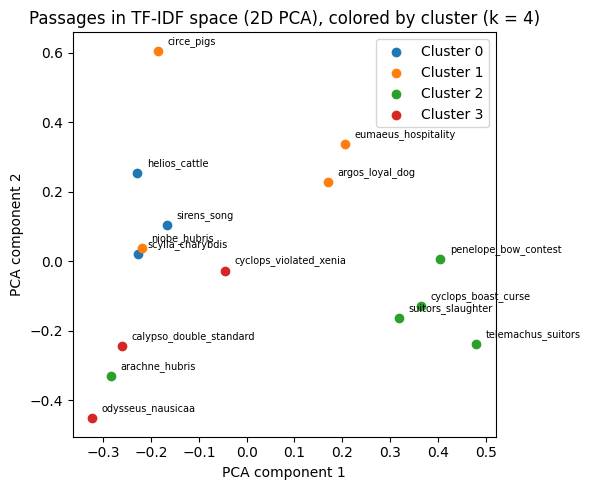

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Build TF-IDF matrix once
X, vectorizer = build_tfidf(myths)
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF shape (documents, features):", X.shape)

# 2. Run k-means for k = 4
k = 4
kmeans, labels_k4 = run_kmeans(X, k)

# 3. Build a clean DataFrame for the k = 4 model (Table 1)
rows_k4 = []
for myth, label in zip(myths, labels_k4):
    rows_k4.append({
        "id": myth["id"],
        "title": myth["title"],
        "work": myth["work"],
        "cluster_k4": int(label),
        "tags": ", ".join(myth["tags"])
    })

df_k4 = pd.DataFrame(rows_k4).sort_values(by=["cluster_k4", "work", "id"])
display(df_k4)  # This is Table 1 in the paper

# 4. 2D PCA scatter plot colored by cluster (Figure 1)
pca = PCA(n_components=2, random_state=0)
X_2d = pca.fit_transform(X.toarray())

plt.figure(figsize=(6, 5))
for cluster_id in range(k):
    mask = labels_k4 == cluster_id
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"Cluster {cluster_id}")

# Annotate each point with myth id
for i, myth in enumerate(myths):
    plt.text(X_2d[i, 0] + 0.02, X_2d[i, 1] + 0.02, myth["id"], fontsize=7)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Passages in TF-IDF space (2D PCA), colored by cluster (k = 4)")
plt.legend()
plt.tight_layout()
plt.show()






## 4. Results: Comparing k = 3, 4, and 5

This section shows how each passage's cluster assignment changes when I vary k.


In [4]:
# Run k-means for k = 3, 4, 5
k_values = [3, 4, 5]
labels_dict = {}

for k in k_values:
    _, labels = run_kmeans(X, k)
    labels_dict[k] = labels

# Build comparison table (Table 2)
rows_compare = []
for idx, myth in enumerate(myths):
    rows_compare.append({
        "id": myth["id"],
        "title": myth["title"],
        "cluster_k3": int(labels_dict[3][idx]),
        "cluster_k4": int(labels_dict[4][idx]),
        "cluster_k5": int(labels_dict[5][idx]),
    })

df_compare = pd.DataFrame(rows_compare).sort_values(by="id")
display(df_compare)  # This is Table 2 in the paper



,id,title,cluster_k3,cluster_k4,cluster_k5
8,arachne_hubris,Arachne Challenges Minerva,2,2,3
11,argos_loyal_dog,Argos Recognizes Odysseus,0,1,0
6,calypso_double_standard,Calypso Complains About the Gods,2,3,1
4,circe_pigs,Circe Turns the Men into Swine,0,1,0
2,cyclops_boast_curse,Odysseus’ Boast and the Cyclops’ Curse,1,2,2
1,cyclops_violated_xenia,Polyphemus Rejects Hospitality,0,3,1
10,eumaeus_hospitality,Eumaeus Welcomes the Stranger,0,1,0
5,helios_cattle,The Slaughter of Helios’ Cattle,0,0,1
9,niobe_hubris,Niobe’s Fall and Transformation,0,1,4
3,odysseus_nausicaa,Odysseus Speaks to Nausicaa,2,3,3


## Appendix: Full Text Cluster Summaries

I used this helper to generate the long cluster summaries I quoted in the commentary.


In [5]:
from collections import Counter

def analyze_k(k):
    """
    Run TF-IDF + k-means for a given k and print:
    - myths in each cluster
    - top words per cluster
    - tag counts per cluster
    """
    print("=" * 80)
    print(f"FULL ANALYSIS FOR k = {k}")
    print("=" * 80)

    X, vectorizer = build_tfidf(myths)
    kmeans, labels = run_kmeans(X, k)
    feature_names = vectorizer.get_feature_names_out()
    centers = kmeans.cluster_centers_

    for cluster_id in range(k):
        print("\n" + "-" * 80)
        print(f"Cluster {cluster_id} (k = {k})")
        print("-" * 80)

        cluster_myths = [
            (myth["id"], myth["title"])
            for myth, label in zip(myths, labels)
            if label == cluster_id
        ]
        print("Myths in this cluster:")
        if not cluster_myths:
            print(" (no myths assigned)")
        else:
            for mid, title in cluster_myths:
                print(f"  - {mid} — {title}")

        sorted_idx = centers[cluster_id].argsort()
        top_idx = sorted_idx[-10:]
        top_words = feature_names[top_idx]
        print("\nTop words (approx. cluster theme):")
        print("  " + ", ".join(top_words))

        cluster_tags = []
        for myth, label in zip(myths, labels):
            if label == cluster_id:
                cluster_tags.extend(myth["tags"])

        print("\nTag counts:")
        if not cluster_tags:
            print("  (no tags, cluster empty)")
        else:
            counts = Counter(cluster_tags)
            for tag, count in counts.most_common():
                print(f"  {tag}: {count}")

    print("\n" + "=" * 80)
    print(f"END OF ANALYSIS FOR k = {k}")
    print("=" * 80)


Notebook last updated: Nov 2025. All code by Damian Martinez.